In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ncr_ride_bookings.csv")

In [4]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 150000
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for can

In [6]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


#### Booking Status Analysis

In [7]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

#### Booking status percentage

In [8]:
booking_status_pct = df["Booking Status"].value_counts(normalize=True) * 100

print(booking_status_pct.round(2))

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


#### Vehicle Type Analysis

In [9]:
df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

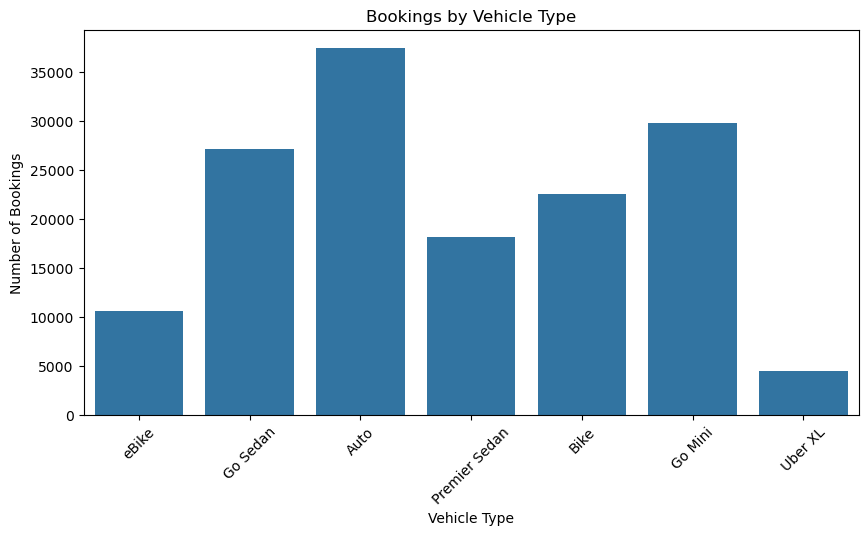

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Vehicle Type")

plt.title("Bookings by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

#### Revenue Analysis

In [11]:
total_revenue = df["Booking Value"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 51846183.0


#### Revenue distribution

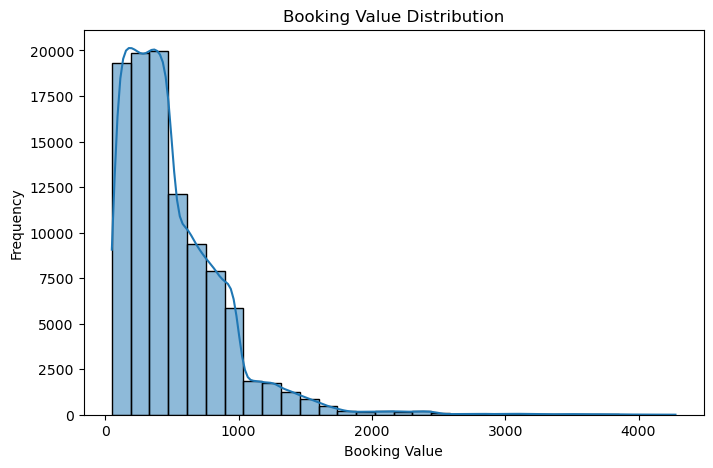

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Booking Value"], bins=30, kde=True)

plt.title("Booking Value Distribution")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")
plt.show()

#### Ride Distance Analysis

In [13]:
df["Ride Distance"].describe()

count    102000.000000
mean         24.637012
std          14.002138
min           1.000000
25%          12.460000
50%          23.720000
75%          36.820000
max          50.000000
Name: Ride Distance, dtype: float64

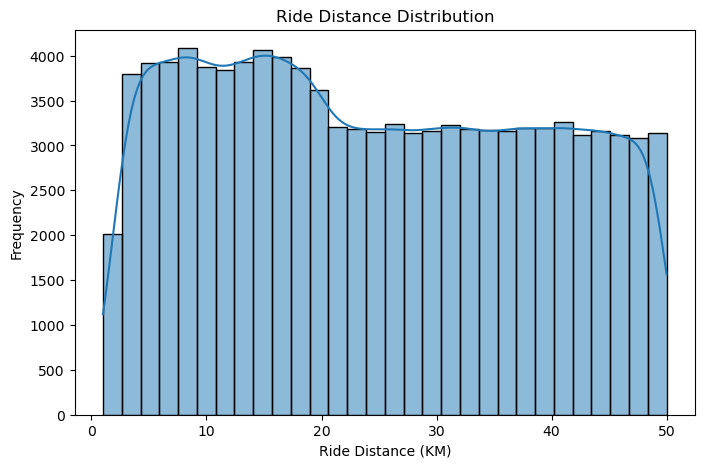

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Ride Distance"], bins=30, kde=True)

plt.title("Ride Distance Distribution")
plt.xlabel("Ride Distance (KM)")
plt.ylabel("Frequency")
plt.show()

#### Cancellation Analysis

In [15]:
df["Cancelled Rides by Customer"].value_counts(dropna=False)

Cancelled Rides by Customer
NaN    139500
1.0     10500
Name: count, dtype: int64

In [16]:
df["Cancelled Rides by Driver"].value_counts(dropna=False)

Cancelled Rides by Driver
NaN    123000
1.0     27000
Name: count, dtype: int64

In [17]:
df["Reason for cancelling by Customer"].value_counts(dropna=False)

Reason for cancelling by Customer
NaN                                             139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64

In [18]:
df["Driver Cancellation Reason"].value_counts(dropna=False)

Driver Cancellation Reason
NaN                                    123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

#### Customer cancellation visualization

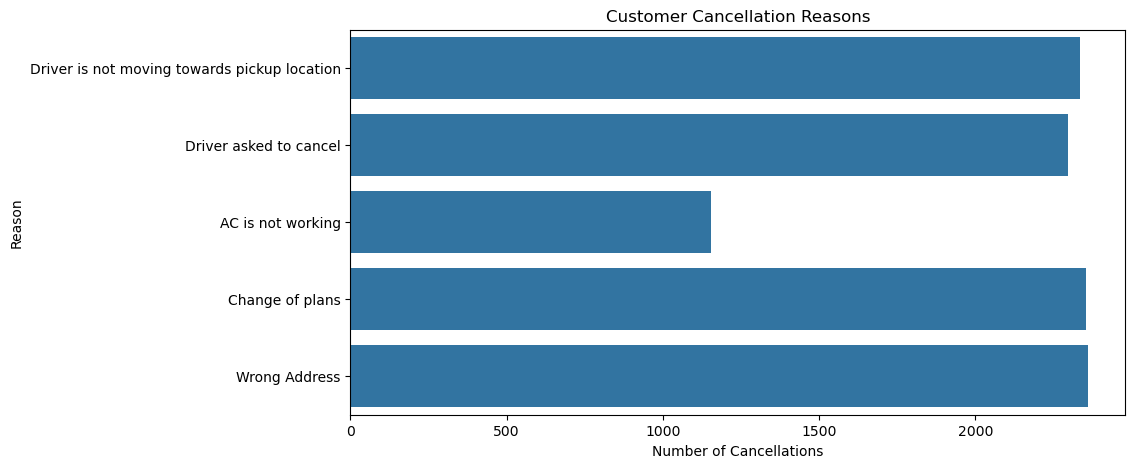

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Reason for cancelling by Customer"
)

plt.title("Customer Cancellation Reasons")
plt.xlabel("Number of Cancellations")
plt.ylabel("Reason")
plt.show()

#### Payment Method Analysis 

In [20]:
df["Payment Method"].value_counts()

Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

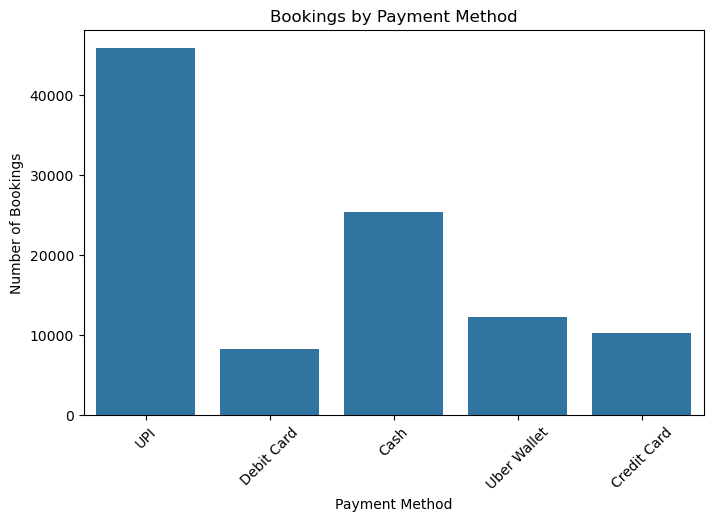

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Payment Method")

plt.title("Bookings by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

#### Ratings Analysis 

In [22]:
#Driver ratings 

In [23]:
df["Driver Ratings"].describe()

count    93000.000000
mean         4.230992
std          0.436871
min          3.000000
25%          4.100000
50%          4.300000
75%          4.600000
max          5.000000
Name: Driver Ratings, dtype: float64

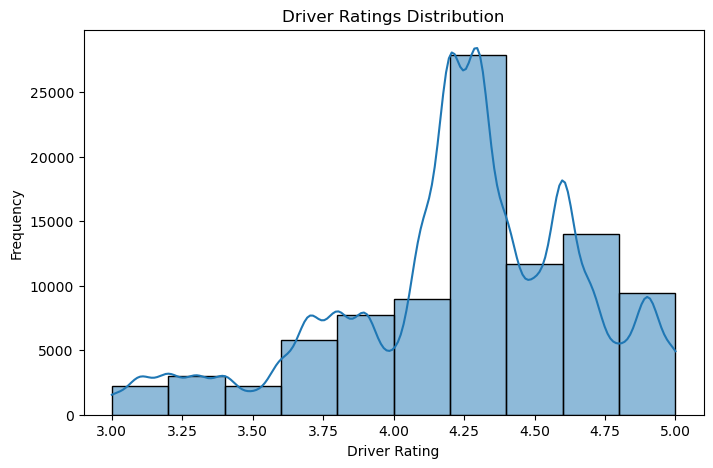

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Driver Ratings"], bins=10, kde=True)

plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")
plt.show()

In [25]:
df["Customer Rating"].describe()

count    93000.000000
mean         4.404584
std          0.437819
min          3.000000
25%          4.200000
50%          4.500000
75%          4.800000
max          5.000000
Name: Customer Rating, dtype: float64

### Time-Based Analysis

#### Booking count by day

In [27]:
df["Date"] = pd.to_datetime(df["Date"])

In [28]:
df["Day"] = df["Date"].dt.day_name()

In [29]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_bookings = df["Day"].value_counts().reindex(day_order)

print(day_bookings)

Day
Monday       21644
Tuesday      21391
Wednesday    21413
Thursday     21215
Friday       21397
Saturday     21542
Sunday       21398
Name: count, dtype: int64


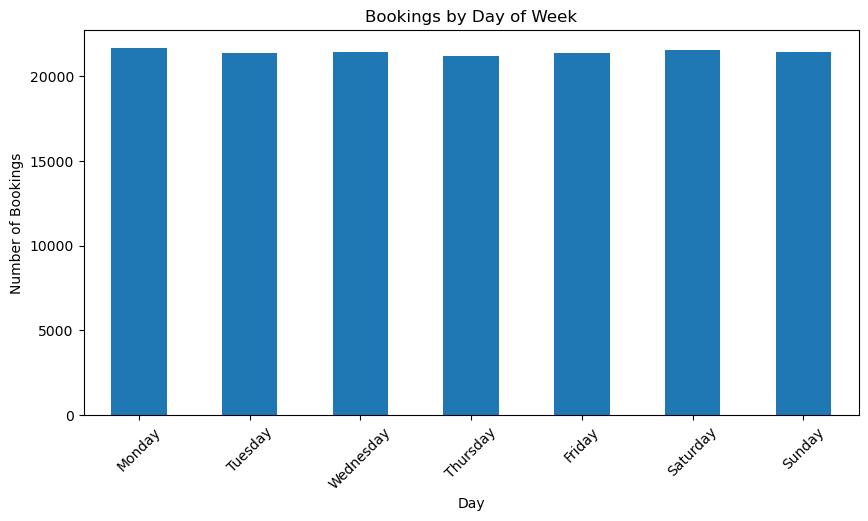

In [30]:
plt.figure(figsize=(10,5))

day_bookings.plot(kind="bar")

plt.title("Bookings by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

#### Monthly Analysis

In [31]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_bookings = df.groupby("Month").size()

print(monthly_bookings)

Month
2024-01    12861
2024-02    11927
2024-03    12719
2024-04    12199
2024-05    12778
2024-06    12440
2024-07    12897
2024-08    12636
2024-09    12248
2024-10    12651
2024-11    12394
2024-12    12250
dtype: int64


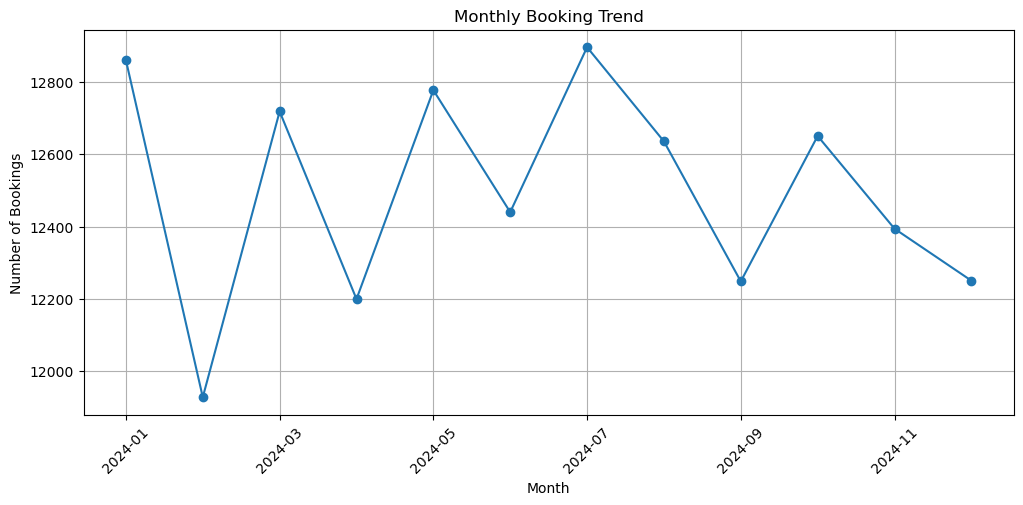

In [32]:
plt.figure(figsize=(12,5))

monthly_bookings.plot(kind="line", marker="o")

plt.title("Monthly Booking Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.grid()
plt.show()

#### Vehicle Type vs Average Revenue

In [36]:
# revenue of vehicle 

In [35]:
vehicle_revenue = (
    df.groupby("Vehicle Type")["Booking Value"]
    .sum()
    .sort_values(ascending=False)
)

print(vehicle_revenue)

Vehicle Type
Auto             12878422.0
Go Mini          10338496.0
Go Sedan          9369719.0
Bike              7837697.0
Premier Sedan     6275332.0
eBike             3618485.0
Uber XL           1528032.0
Name: Booking Value, dtype: float64


In [37]:
# avg revenue 

In [33]:
vehicle_avg_revenue = (
    df.groupby("Vehicle Type")["Booking Value"]
    .mean()
    .sort_values(ascending=False)
)

print(vehicle_avg_revenue.round(2))

Vehicle Type
Go Sedan         511.50
Bike             510.20
Premier Sedan    509.57
Go Mini          507.68
Auto             506.73
eBike            503.90
Uber XL          501.82
Name: Booking Value, dtype: float64



#### Key EDA Insights

1. Identify the most common booking status.
2. Identify the most frequently used vehicle type.
3. Calculate total and average booking value.
4. Identify the major customer and driver cancellation reasons.
5. Identify the busiest days/months.
6. Compare revenue across vehicle types.
7. Analyze ride-distance patterns.
8. Identify important relationships between numerical variables.

    